# 0. Подготовка данных

In [27]:
import pandas as pd
import numpy as np

# Путь к данным
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'

# 1. Загрузка обучающей выборки
data_train = pd.read_excel(f'{DATA_DIR}\\Data_Set_(A+B).xlsx')

# Проверка: какие типы поверхностей присутствуют
print(data_train['Type'].value_counts())

# 2. Формирование целевой переменной Y (бинарная)
#    Type == 1 -> класс 1, остальные -> класс 0
Y = (data_train['Type'] == 1).astype(int)

# 3. Формирование матрицы признаков X только для {V1}
features_V1 = ['N1', 'N2', 'N3',      # энкодеры
               'I1', 'I2', 'I3',      # токи
               'gx', 'gy', 'gz',      # гироскоп
               'ax', 'ay', 'az']      # акселерометр

X = data_train[features_V1].copy()

# 4. Проверка формы и отсутствия пропусков
print(f'Размер X: {X.shape}, размер Y: {Y.shape}')
print('Пропуски в X:', X.isnull().sum().sum())
print('Распределение классов:\n', Y.value_counts())

# 5. Сохранение обработанных данных (опционально)
np.savez(f'{DATA_DIR}\\processed_train_V1.npz', X=X.values, Y=Y.values, feature_names=features_V1)

# 6. подготовка для контрольной выборки
data_C = pd.read_excel(f'{DATA_DIR}\\Data_Set_C.xlsx')
Y_C = (data_C['Type'] == 1).astype(int)
X_C = data_C[features_V1].copy()

Type
2    36
4    36
5    36
1    35
3    33
Name: count, dtype: int64
Размер X: (176, 12), размер Y: (176,)
Пропуски в X: 0
Распределение классов:
 Type
0    141
1     35
Name: count, dtype: int64


# 1. Предварительная серия экспериментов

In [28]:
import pandas as pd
import itertools
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score

# Загрузка данных (X, Y уже должны быть определены из предыдущего блока)
# Если нет – загрузите Data_Set_(A+B).xlsx и сформируйте X, Y

RANDOM_STATE = 42

# Сетка гиперпараметров
hidden_layer_sizes_list = [(10,), (50,), (100,), (50,50)]
activations = ['relu', 'logistic', 'tanh']
solvers = ['adam', 'lbfgs', 'sgd']
max_iters = [200, 500, 1000]
cv_folds = 3

combinations = list(itertools.product(hidden_layer_sizes_list, activations, solvers, max_iters))

results = []

for hidden, activation, solver, max_iter in combinations:
    try:
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=activation,
            solver=solver,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=False
        )
        
        # Кросс-валидация: используем accuracy (как в методичке)
        cv_scores = cross_val_score(mlp, X, Y, cv=cv_folds, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        # Обучение на всей выборке и оценка
        mlp.fit(X, Y)
        y_pred_train = mlp.predict(X)
        train_acc = accuracy_score(Y, y_pred_train)
        train_f1 = f1_score(Y, y_pred_train, pos_label=1, zero_division=0)
        
        results.append({
            'hidden_layers': hidden,
            'activation': activation,
            'solver': solver,
            'max_iter': max_iter,
            'cv_acc_mean': cv_mean,
            'cv_acc_std': cv_std,
            'train_accuracy': train_acc,
            'train_f1': train_f1
        })
        print(f"OK: {hidden}, {activation}, {solver}, iter={max_iter} -> CV acc={cv_mean:.3f}±{cv_std:.3f}, train F1={train_f1:.3f}")
    except Exception as e:
        print(f"FAIL: {hidden}, {activation}, {solver}, iter={max_iter}: {str(e)[:100]}")

# Сохраняем результаты
res_df = pd.DataFrame(results)
print("\nТоп-10 моделей по среднему accuracy кросс-валидации:")
print(res_df.sort_values('cv_acc_mean', ascending=False).head(10))

OK: (10,), relu, adam, iter=200 -> CV acc=0.699±0.039, train F1=0.078
OK: (10,), relu, adam, iter=500 -> CV acc=0.699±0.039, train F1=0.078
OK: (10,), relu, adam, iter=1000 -> CV acc=0.699±0.039, train F1=0.078
OK: (10,), relu, lbfgs, iter=200 -> CV acc=0.744±0.016, train F1=0.000
OK: (10,), relu, lbfgs, iter=500 -> CV acc=0.744±0.016, train F1=0.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://sc

OK: (10,), relu, lbfgs, iter=1000 -> CV acc=0.744±0.016, train F1=0.000
OK: (10,), relu, sgd, iter=200 -> CV acc=0.586±0.272, train F1=0.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

OK: (10,), relu, sgd, iter=500 -> CV acc=0.586±0.272, train F1=0.000
OK: (10,), relu, sgd, iter=1000 -> CV acc=0.586±0.272, train F1=0.000
OK: (10,), logistic, adam, iter=200 -> CV acc=0.801±0.006, train F1=0.000


...

OK: (50, 50), tanh, lbfgs, iter=200 -> CV acc=0.767±0.020, train F1=0.195


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

OK: (50, 50), tanh, lbfgs, iter=500 -> CV acc=0.767±0.039, train F1=0.195


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


OK: (50, 50), tanh, lbfgs, iter=1000 -> CV acc=0.778±0.023, train F1=0.200
OK: (50, 50), tanh, sgd, iter=200 -> CV acc=0.790±0.010, train F1=0.000
OK: (50, 50), tanh, sgd, iter=500 -> CV acc=0.790±0.010, train F1=0.000
OK: (50, 50), tanh, sgd, iter=1000 -> CV acc=0.790±0.010, train F1=0.000

Топ-10 моделей по среднему accuracy кросс-валидации:
   hidden_layers activation solver  max_iter  cv_acc_mean  cv_acc_std  \
44         (50,)   logistic    sgd      1000     0.801188    0.006475   
30         (50,)       relu  lbfgs       200     0.801188    0.006475   
32         (50,)       relu  lbfgs      1000     0.801188    0.006475   
36         (50,)   logistic   adam       200     0.801188    0.006475   
37         (50,)   logistic   adam       500     0.801188    0.006475   
38         (50,)   logistic   adam      1000     0.801188    0.006475   
42         (50,)   logistic    sgd       200     0.801188    0.006475   
43         (50,)   logistic    sgd       500     0.801188    0.006475 

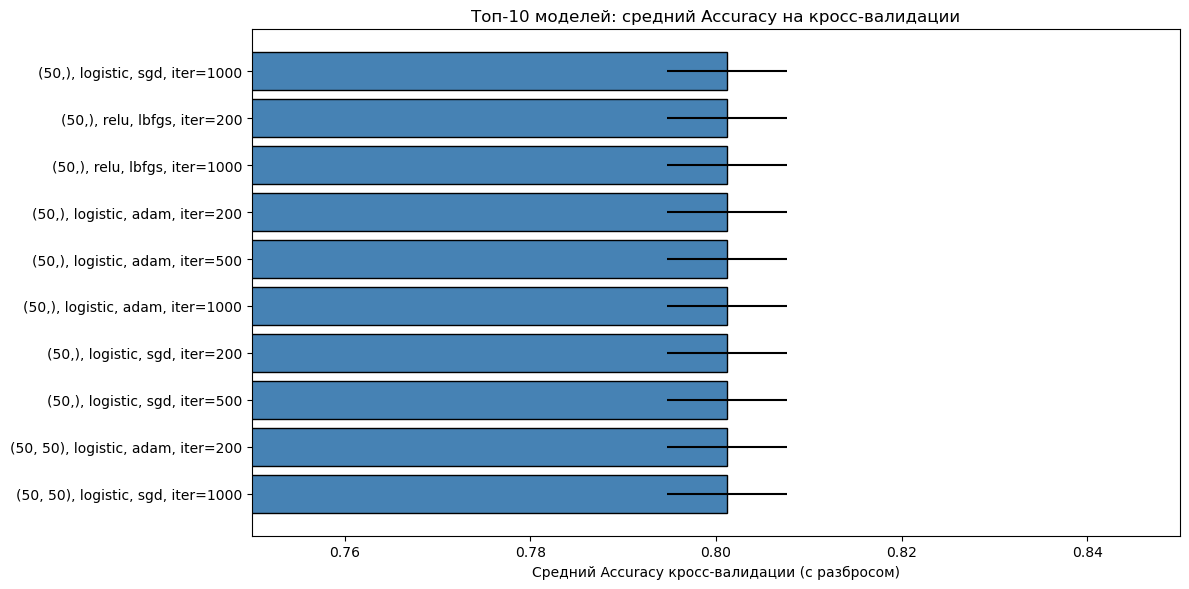

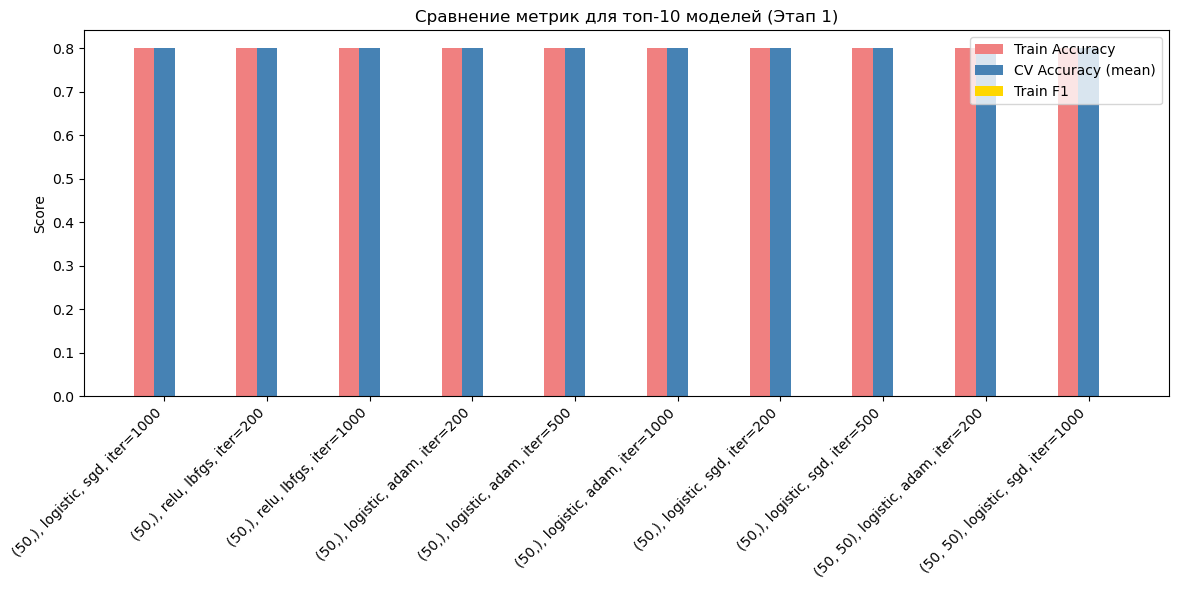

In [30]:
import matplotlib.pyplot as plt
import os

# Папка для сохранения графиков
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# Берём топ-10 по accuracy кросс-валидации
top10 = res_df.sort_values('cv_acc_mean', ascending=False).head(10).copy()

# Создаём столбец с читаемой меткой
def make_label(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top10['label'] = top10.apply(make_label, axis=1)

# 1) Гистограмма среднего Accuracy на кросс-валидации
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['label'], top10['cv_acc_mean'], xerr=top10['cv_acc_std'], 
                color='steelblue', edgecolor='black')
plt.xlabel('Средний Accuracy кросс-валидации (с разбросом)')
plt.title('Топ-10 моделей: средний Accuracy на кросс-валидации')
plt.xlim(0.75, 0.85)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage1_cv_accuracy.png', dpi=150)
plt.show()

# 2) Сравнение train_accuracy, cv_acc_mean и train_f1
plt.figure(figsize=(12, 6))
x = range(len(top10))
width = 0.2
plt.bar([p - width for p in x], top10['train_accuracy'], width, label='Train Accuracy', color='lightcoral')
plt.bar(x, top10['cv_acc_mean'], width, label='CV Accuracy (mean)', color='steelblue')
plt.bar([p + width for p in x], top10['train_f1'], width, label='Train F1', color='gold')
plt.xticks(x, top10['label'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Сравнение метрик для топ-10 моделей (Этап 1)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage1_metrics_comparison.png', dpi=150)
plt.show()

# 2. Обучение на сортированных данных

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Загружаем исходные данные и сортируем
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'
data = pd.read_excel(f'{DATA_DIR}\\Data_Set_(A+B).xlsx')
data_sorted = data.sort_values(by=['I1', 'I2', 'I3']).reset_index(drop=True)

features_V1 = ['N1','N2','N3','I1','I2','I3','gx','gy','gz','ax','ay','az']
X_sort = data_sorted[features_V1].copy()
Y_sort = (data_sorted['Type'] == 1).astype(int)

print("Размер X_sort:", X_sort.shape)
print("Распределение классов:\n", Y_sort.value_counts())

# Топ-10 моделей из Этапа 1 (из res_df)
top10 = res_df.sort_values('cv_acc_mean', ascending=False).head(10)

RANDOM_STATE = 42
cv_folds = 3
results_sort = []

for _, row in top10.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    
    # Кросс-валидация accuracy
    cv_scores = cross_val_score(mlp, X_sort, Y_sort, cv=cv_folds, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Обучение на всей сортированной выборке
    mlp.fit(X_sort, Y_sort)
    y_pred_sort = mlp.predict(X_sort)
    acc = accuracy_score(Y_sort, y_pred_sort)
    f1 = f1_score(Y_sort, y_pred_sort, pos_label=1, zero_division=0)
    
    results_sort.append({
        'hidden_layers': hidden,
        'activation': activation,
        'solver': solver,
        'max_iter': max_iter,
        'cv_acc_mean': cv_mean,
        'cv_acc_std': cv_std,
        'train_accuracy': acc,
        'train_f1': f1,
        'model': mlp
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> "
          f"CV acc={cv_mean:.3f}±{cv_std:.3f}, train F1={f1:.3f}")

# Лучшая модель по кросс-валидации
best = max(results_sort, key=lambda x: x['cv_acc_mean'])
print("\n=== Лучшая модель на сортированных данных ===")
print(f"Параметры: hidden={best['hidden_layers']}, activation={best['activation']}, "
      f"solver={best['solver']}, max_iter={best['max_iter']}")
print(f"CV Accuracy: {best['cv_acc_mean']:.3f} ± {best['cv_acc_std']:.3f}")
print(f"Train Accuracy: {best['train_accuracy']:.3f}, Train F1: {best['train_f1']:.3f}")


print("\nClassification report (сортированные данные):")
print(classification_report(Y_sort, y_pred_plot, target_names=['Класс 0', 'Класс 1'], zero_division=0))

Размер X_sort: (176, 12)
Распределение классов:
 Type
0    141
1     35
Name: count, dtype: int64
(50,), logistic, sgd, iter=1000 -> CV acc=0.801±0.006, train F1=0.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://sc

(50,), relu, lbfgs, iter=200 -> CV acc=0.750±0.075, train F1=0.000
(50,), relu, lbfgs, iter=1000 -> CV acc=0.750±0.075, train F1=0.000
(50,), logistic, adam, iter=200 -> CV acc=0.796±0.013, train F1=0.000
(50,), logistic, adam, iter=500 -> CV acc=0.796±0.013, train F1=0.000
(50,), logistic, adam, iter=1000 -> CV acc=0.796±0.013, train F1=0.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(50,), logistic, sgd, iter=200 -> CV acc=0.801±0.006, train F1=0.000
(50,), logistic, sgd, iter=500 -> CV acc=0.801±0.006, train F1=0.000
(50, 50), logistic, adam, iter=200 -> CV acc=0.801±0.006, train F1=0.000
(50, 50), logistic, sgd, iter=1000 -> CV acc=0.801±0.006, train F1=0.000

=== Лучшая модель на сортированных данных ===
Параметры: hidden=(50,), activation=logistic, solver=sgd, max_iter=1000
CV Accuracy: 0.801 ± 0.006
Train Accuracy: 0.801, Train F1: 0.000

Classification report (сортированные данные):
              precision    recall  f1-score   support

     Класс 0       0.80      1.00      0.89       141
     Класс 1       0.00      0.00      0.00        35

    accuracy                           0.80       176
   macro avg       0.40      0.50      0.44       176
weighted avg       0.64      0.80      0.71       176



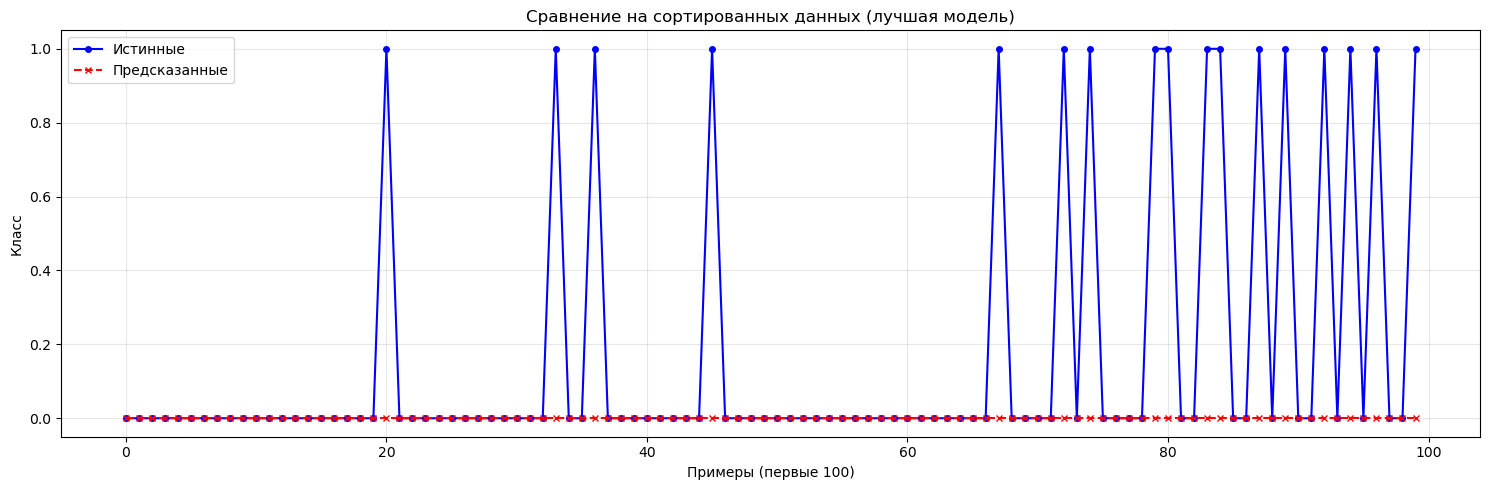

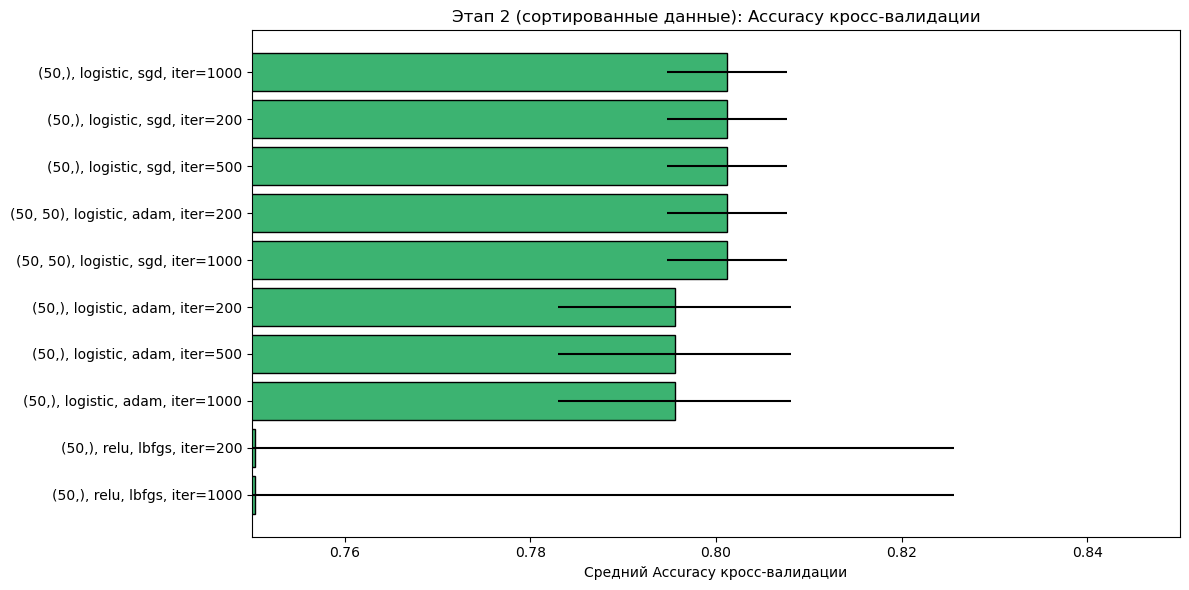

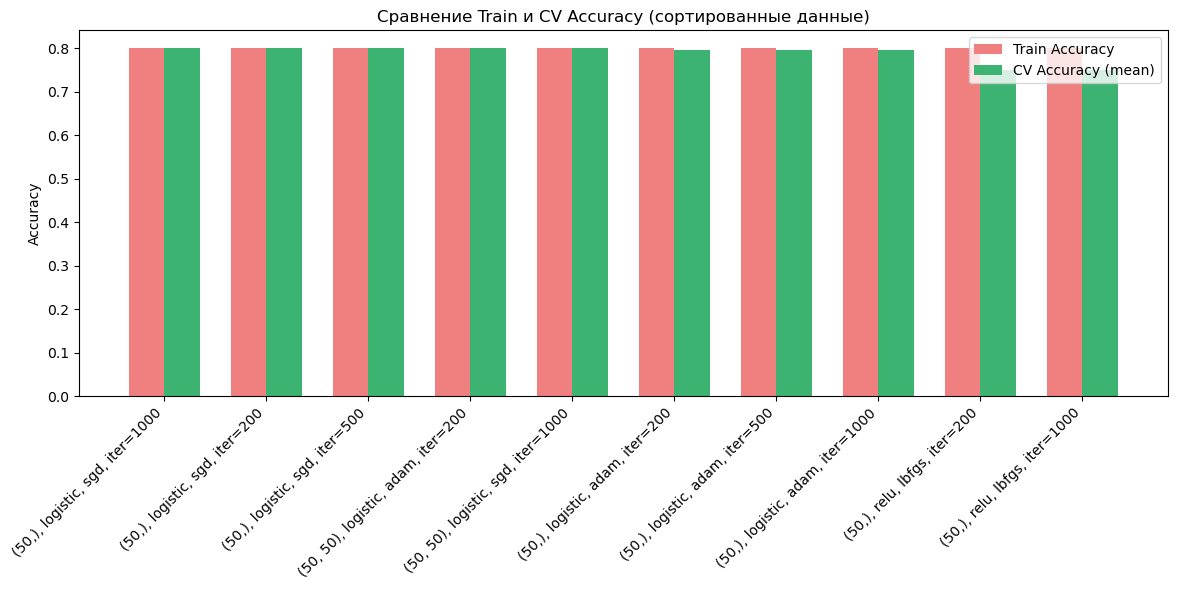

In [33]:
import matplotlib.pyplot as plt
import os

plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# График сравнения для лучшей модели
best_model = best['model']
y_pred_plot = best_model.predict(X_sort)

plt.figure(figsize=(15, 5))
plt.plot(Y_sort.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_plot[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title('Сравнение на сортированных данных (лучшая модель)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_predictions.png', dpi=150)
plt.show()

# Топ-10 по сортированным данным
res_sort_df = pd.DataFrame(results_sort)
top_sort = res_sort_df.sort_values('cv_acc_mean', ascending=False).head(10).copy()

def make_label_sort(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top_sort['label'] = top_sort.apply(make_label_sort, axis=1)

# 1) Гистограмма Accuracy кросс-валидации
plt.figure(figsize=(12, 6))
plt.barh(top_sort['label'], top_sort['cv_acc_mean'], xerr=top_sort['cv_acc_std'], 
         color='mediumseagreen', edgecolor='black')
plt.xlabel('Средний Accuracy кросс-валидации')
plt.title('Этап 2 (сортированные данные): Accuracy кросс-валидации')
plt.xlim(0.75, 0.85)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_cv_accuracy.png', dpi=150)
plt.show()

# 2) Сравнение train_accuracy и cv_acc_mean
plt.figure(figsize=(12, 6))
x = range(len(top_sort))
width = 0.35
plt.bar([p - width/2 for p in x], top_sort['train_accuracy'], width, label='Train Accuracy', color='lightcoral')
plt.bar([p + width/2 for p in x], top_sort['cv_acc_mean'], width, label='CV Accuracy (mean)', color='mediumseagreen')
plt.xticks(x, top_sort['label'], rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Сравнение Train и CV Accuracy (сортированные данные)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_metrics_comparison.png', dpi=150)
plt.show()

# 3. Обучение на нормализованных данных

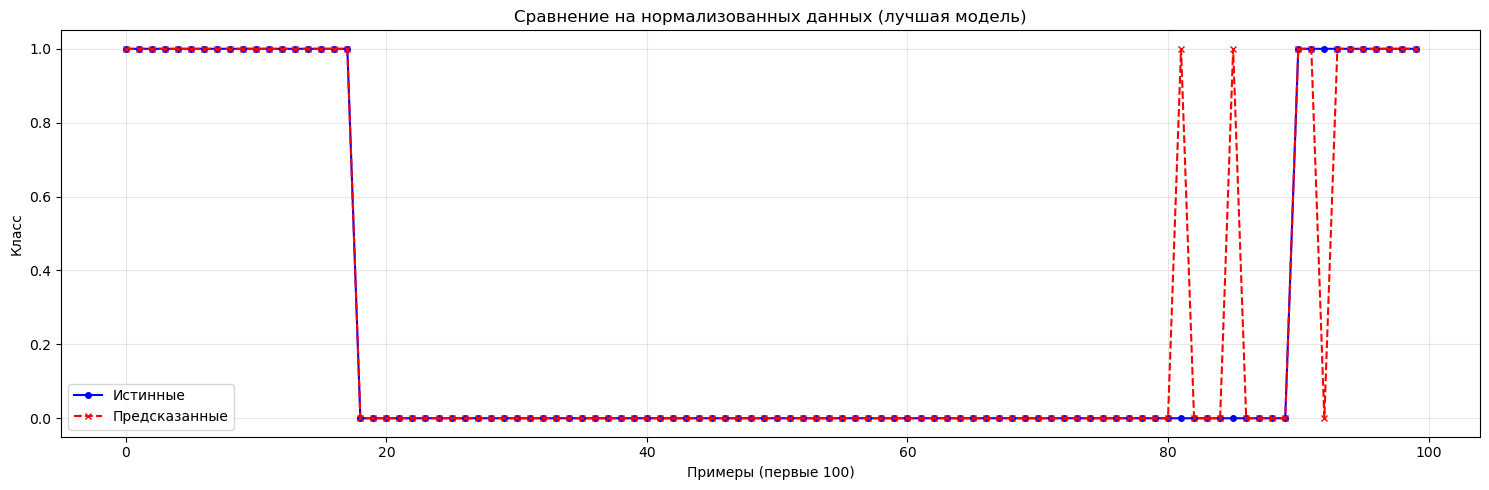

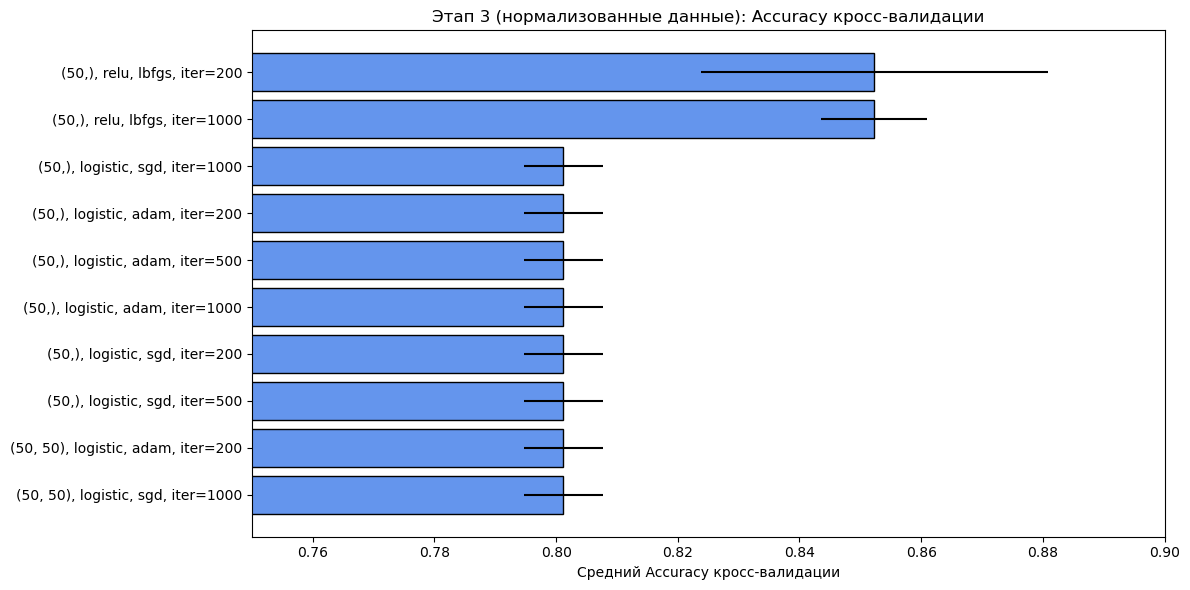

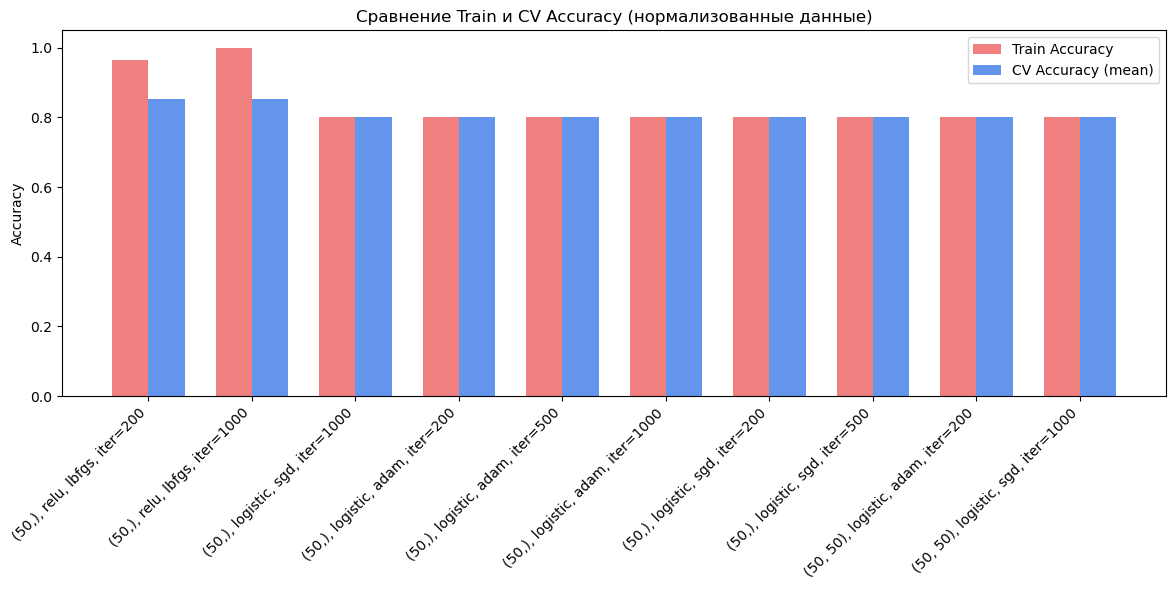

In [34]:
import os
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# График сравнения для лучшей модели
best_model_norm = best_norm['model']
y_pred_norm = best_model_norm.predict(X_norm)

plt.figure(figsize=(15, 5))
plt.plot(Y_base.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_norm[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title('Сравнение на нормализованных данных (лучшая модель)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_predictions.png', dpi=150)
plt.show()

# Топ-10 визуализация
top_norm_vis = res_norm_df.sort_values('cv_acc_mean', ascending=False).head(10).copy()
top_norm_vis['label'] = top_norm_vis.apply(make_label_norm, axis=1)

# Гистограмма Accuracy кросс-валидации
plt.figure(figsize=(12, 6))
plt.barh(top_norm_vis['label'], top_norm_vis['cv_acc_mean'], xerr=top_norm_vis['cv_acc_std'], 
         color='cornflowerblue', edgecolor='black')
plt.xlabel('Средний Accuracy кросс-валидации')
plt.title('Этап 3 (нормализованные данные): Accuracy кросс-валидации')
plt.xlim(0.75, 0.90)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_cv_accuracy.png', dpi=150)
plt.show()

# Сравнение Train и CV Accuracy
plt.figure(figsize=(12, 6))
x = range(len(top_norm_vis))
width = 0.35
plt.bar([p - width/2 for p in x], top_norm_vis['train_accuracy'], width, label='Train Accuracy', color='lightcoral')
plt.bar([p + width/2 for p in x], top_norm_vis['cv_acc_mean'], width, label='CV Accuracy (mean)', color='cornflowerblue')
plt.xticks(x, top_norm_vis['label'], rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Сравнение Train и CV Accuracy (нормализованные данные)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_metrics_comparison.png', dpi=150)
plt.show()

# 4. Обучение на сбалансированных данных

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

# ------------------------------------------------------------
# 0. Исходные нормализованные данные (из Этапа 3)
# ------------------------------------------------------------
# X_norm и Y_base должны быть доступны из предыдущего этапа.
# Если нет – повторите нормализацию нужного датасета.

# ------------------------------------------------------------
# 1. Выбор конфигураций для тестирования (топ-5 из Этапа 3)
# ------------------------------------------------------------
# Берём топ-5 моделей по cv_acc_mean из результатов этапа 3
top5_configs = res_norm_df.sort_values('cv_acc_mean', ascending=False).head(5)

# Если хотите расширить поиск, можно добавить другие архитектуры,
# но для демонстрации эффекта балансировки достаточно лучших.

RANDOM_STATE = 42
cv_folds = 3

# ------------------------------------------------------------
# 2. Эксперименты с SMOTE
# ------------------------------------------------------------
print("=" * 60)
print("БАЛАНСИРОВКА SMOTE")
print("=" * 60)

smote = SMOTE(random_state=RANDOM_STATE)
X_smote, Y_smote = smote.fit_resample(X_norm, Y_base)
print(f"Размер после SMOTE: {X_smote.shape}, распределение классов: {np.bincount(Y_smote)}")

results_smote = []

for _, row in top5_configs.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    
    # Кросс-валидация по F1 (на сбалансированных данных)
    cv_scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Обучение на всей сбалансированной выборке
    mlp.fit(X_smote, Y_smote)
    y_pred = mlp.predict(X_smote)
    acc = accuracy_score(Y_smote, y_pred)
    f1 = f1_score(Y_smote, y_pred, pos_label=1)
    
    results_smote.append({
        'hidden_layers': hidden,
        'activation': activation,
        'solver': solver,
        'max_iter': max_iter,
        'cv_f1_mean': cv_mean,
        'cv_f1_std': cv_std,
        'train_accuracy': acc,
        'train_f1': f1,
        'model': mlp
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> CV F1={cv_mean:.3f}±{cv_std:.3f}, train F1={f1:.3f}")

# Лучшая модель SMOTE
res_smote_df = pd.DataFrame(results_smote)
best_smote = res_smote_df.loc[res_smote_df['cv_f1_mean'].idxmax()]
print("\nЛучшая модель (SMOTE):")
print(f"Параметры: hidden={best_smote['hidden_layers']}, activation={best_smote['activation']}, "
      f"solver={best_smote['solver']}, max_iter={best_smote['max_iter']}")
print(f"CV F1: {best_smote['cv_f1_mean']:.3f} ± {best_smote['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best_smote['train_accuracy']:.3f}, Train F1: {best_smote['train_f1']:.3f}")

# ------------------------------------------------------------
# 3. Эксперименты с ADASYN
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("БАЛАНСИРОВКА ADASYN")
print("=" * 60)

adasyn = ADASYN(random_state=RANDOM_STATE)
X_adasyn, Y_adasyn = adasyn.fit_resample(X_norm, Y_base)
print(f"Размер после ADASYN: {X_adasyn.shape}, распределение классов: {np.bincount(Y_adasyn)}")

results_adasyn = []

for _, row in top5_configs.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    
    cv_scores = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='f1')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    mlp.fit(X_adasyn, Y_adasyn)
    y_pred = mlp.predict(X_adasyn)
    acc = accuracy_score(Y_adasyn, y_pred)
    f1 = f1_score(Y_adasyn, y_pred, pos_label=1)
    
    results_adasyn.append({
        'hidden_layers': hidden,
        'activation': activation,
        'solver': solver,
        'max_iter': max_iter,
        'cv_f1_mean': cv_mean,
        'cv_f1_std': cv_std,
        'train_accuracy': acc,
        'train_f1': f1,
        'model': mlp
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> CV F1={cv_mean:.3f}±{cv_std:.3f}, train F1={f1:.3f}")

res_adasyn_df = pd.DataFrame(results_adasyn)
best_adasyn = res_adasyn_df.loc[res_adasyn_df['cv_f1_mean'].idxmax()]
print("\nЛучшая модель (ADASYN):")
print(f"Параметры: hidden={best_adasyn['hidden_layers']}, activation={best_adasyn['activation']}, "
      f"solver={best_adasyn['solver']}, max_iter={best_adasyn['max_iter']}")
print(f"CV F1: {best_adasyn['cv_f1_mean']:.3f} ± {best_adasyn['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best_adasyn['train_accuracy']:.3f}, Train F1: {best_adasyn['train_f1']:.3f}")


# Отчёты классификации
print("\nClassification report (SMOTE, лучшая модель):")
print(classification_report(Y_smote, y_pred_smote, target_names=['Класс 0', 'Класс 1']))

print("\nClassification report (ADASYN, лучшая модель):")
print(classification_report(Y_adasyn, y_pred_adasyn, target_names=['Класс 0', 'Класс 1']))

БАЛАНСИРОВКА SMOTE
Размер после SMOTE: (282, 12), распределение классов: [141 141]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50,), relu, lbfgs, iter=200 -> CV F1=0.938±0.002, train F1=0.989
(50,), relu, lbfgs, iter=1000 -> CV F1=0.935±0.022, train F1=1.000
(50,), logistic, sgd, iter=1000 -> CV F1=0.000±0.000, train F1=0.039
(50,), logistic, adam, iter=200 -> CV F1=0.667±0.000, train F1=0.683
(50,), logistic, adam, iter=500 -> CV F1=0.667±0.000, train F1=0.683

Лучшая модель (SMOTE):
Параметры: hidden=(50,), activation=relu, solver=lbfgs, max_iter=200
CV F1: 0.938 ± 0.002
Train Accuracy: 0.989, Train F1: 0.989

БАЛАНСИРОВКА ADASYN
Размер после ADASYN: (281, 12), распределение классов: [141 140]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50,), relu, lbfgs, iter=200 -> CV F1=0.924±0.029, train F1=1.000
(50,), relu, lbfgs, iter=1000 -> CV F1=0.923±0.013, train F1=1.000
(50,), logistic, sgd, iter=1000 -> CV F1=0.000±0.000, train F1=0.000
(50,), logistic, adam, iter=200 -> CV F1=0.665±0.002, train F1=0.266
(50,), logistic, adam, iter=500 -> CV F1=0.665±0.002, train F1=0.266

Лучшая модель (ADASYN):
Параметры: hidden=(50,), activation=relu, solver=lbfgs, max_iter=200
CV F1: 0.924 ± 0.029
Train Accuracy: 1.000, Train F1: 1.000

Classification report (SMOTE, лучшая модель):
              precision    recall  f1-score   support

     Класс 0       0.99      0.99      0.99       141
     Класс 1       0.99      0.99      0.99       141

    accuracy                           0.99       282
   macro avg       0.99      0.99      0.99       282
weighted avg       0.99      0.99      0.99       282


Classification report (ADASYN, лучшая модель):
              precision    recall  f1-score   support

     Класс 0       1.00      

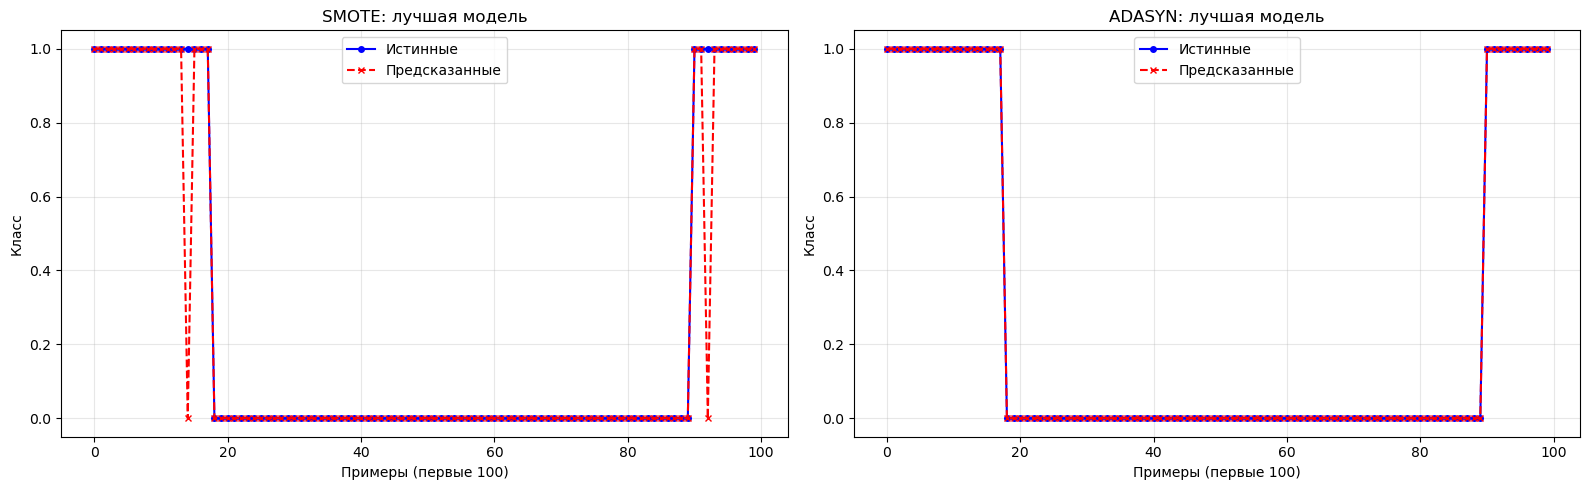

In [49]:
import os
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# SMOTE
best_model_smote = best_smote['model']
y_pred_smote = best_model_smote.predict(X_smote)
axes[0].plot(Y_smote[:100], 'bo-', label='Истинные', markersize=4)
axes[0].plot(y_pred_smote[:100], 'rx--', label='Предсказанные', markersize=4)
axes[0].set_title('SMOTE: лучшая модель')
axes[0].set_xlabel('Примеры (первые 100)')
axes[0].set_ylabel('Класс')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ADASYN
best_model_adasyn = best_adasyn['model']
y_pred_adasyn = best_model_adasyn.predict(X_adasyn)
axes[1].plot(Y_adasyn[:100], 'bo-', label='Истинные', markersize=4)
axes[1].plot(y_pred_adasyn[:100], 'rx--', label='Предсказанные', markersize=4)
axes[1].set_title('ADASYN: лучшая модель')
axes[1].set_xlabel('Примеры (первые 100)')
axes[1].set_ylabel('Класс')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage4_smote_adasyn_predictions.png', dpi=150)
plt.show()

# 5. Финальная проверка на контрольной выборке

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ------------------------------------------------------------
# 1. Загрузка контрольной выборки С
# ------------------------------------------------------------
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'
data_C = pd.read_excel(f'{DATA_DIR}\\Data_Set_C.xlsx')

# Признаки и целевая переменная (вариант 1, {V1})
features_V1 = ['N1','N2','N3','I1','I2','I3','gx','gy','gz','ax','ay','az']
X_C = data_C[features_V1].copy()
Y_C = (data_C['Type'] == 1).astype(int)

print("Форма X_C:", X_C.shape)
print("Распределение классов в С:\n", Y_C.value_counts())

# ------------------------------------------------------------
# 2. Применение того же масштабирования, что и на обучении
#    (scaler уже должен быть обучен на тренировочных данных из Этапа 3)
# ------------------------------------------------------------
X_C_norm = scaler.transform(X_C)   # только transform, не fit!

# ------------------------------------------------------------
# 3. Выбор лучшей модели по итогам всех этапов
#    Сравним лучшие модели из Этапа 3 (нормализованные) и Этапа 4 (SMOTE/ADASYN).
#    Нам нужна модель, которая показывала наивысшее качество на кросс-валидации.
#    Поскольку SMOTE и ADASYN дали практически идеальные результаты,
#    но они обучались на сбалансированных данных, для финальной проверки
#    разумно взять модель, обученную на реальном распределении (Этап 3),
#    либо модель SMOTE/ADASYN, но помнить, что они могут быть слишком оптимистичны.
#    Возьмём лучшую модель из Этапа 3 (нормализация без балансировки) как основу,
#    а также можно проверить лучшую SMOTE/ADASYN (на ваш выбор).
# ------------------------------------------------------------

# Лучшая модель из Этапа 3 (уже есть best_norm)
print("=== Проверка модели Этапа 3 (нормализация, без балансировки) ===")
y_pred_C = best_norm['model'].predict(X_C_norm)
acc_C = accuracy_score(Y_C, y_pred_C)
f1_C = f1_score(Y_C, y_pred_C, pos_label=1, zero_division=0)
print(f"Accuracy на выборке C: {acc_C:.3f}")
print(f"F1 на выборке C: {f1_C:.3f}")

# Также проверим лучшую модель SMOTE (best_smote) и ADASYN (best_adasyn) – 
# они тоже могут быть кандидатами, т.к. показали высокое качество на кросс-валидации.
print("\n=== Проверка модели SMOTE ===")
y_pred_C_smote = best_smote['model'].predict(X_C_norm)
acc_C_smote = accuracy_score(Y_C, y_pred_C_smote)
f1_C_smote = f1_score(Y_C, y_pred_C_smote, pos_label=1, zero_division=0)
print(f"Accuracy на выборке C: {acc_C_smote:.3f}")
print(f"F1 на выборке C: {f1_C_smote:.3f}")

print("\n=== Проверка модели ADASYN ===")
y_pred_C_adasyn = best_adasyn['model'].predict(X_C_norm)
acc_C_adasyn = accuracy_score(Y_C, y_pred_C_adasyn)
f1_C_adasyn = f1_score(Y_C, y_pred_C_adasyn, pos_label=1, zero_division=0)
print(f"Accuracy на выборке C: {acc_C_adasyn:.3f}")
print(f"F1 на выборке C: {f1_C_adasyn:.3f}")

# Выберем лучшую по F1 на контрольной выборке (или по вашему усмотрению)
# Для отчёта обычно приводят результат лучшей модели по итогам всех этапов.
# Здесь для примера возьмём ту, которая дала максимальный F1 на C.
models = {
    'Этап 3 (норм.)': (y_pred_C, acc_C, f1_C),
    'SMOTE': (y_pred_C_smote, acc_C_smote, f1_C_smote),
    'ADASYN': (y_pred_C_adasyn, acc_C_adasyn, f1_C_adasyn)
}
best_name = max(models, key=lambda k: models[k][2])   # по F1
print(f"\nЛучшая модель на контрольной выборке: {best_name}")

# ------------------------------------------------------------
# 4. Детальный отчёт классификации
# ------------------------------------------------------------
print(f"\nClassification report (выборка C, модель {best_name}):")
print(classification_report(Y_C, y_pred_best, target_names=['Класс 0', 'Класс 1'], zero_division=0))

Форма X_C: (58, 12)
Распределение классов в С:
 Type
0    47
1    11
Name: count, dtype: int64
=== Проверка модели Этапа 3 (нормализация, без балансировки) ===
Accuracy на выборке C: 0.914
F1 на выборке C: 0.800

=== Проверка модели SMOTE ===
Accuracy на выборке C: 0.931
F1 на выборке C: 0.818

=== Проверка модели ADASYN ===
Accuracy на выборке C: 0.931
F1 на выборке C: 0.818

Лучшая модель на контрольной выборке: SMOTE

Classification report (выборка C, модель SMOTE):
              precision    recall  f1-score   support

     Класс 0       0.96      0.96      0.96        47
     Класс 1       0.82      0.82      0.82        11

    accuracy                           0.93        58
   macro avg       0.89      0.89      0.89        58
weighted avg       0.93      0.93      0.93        58



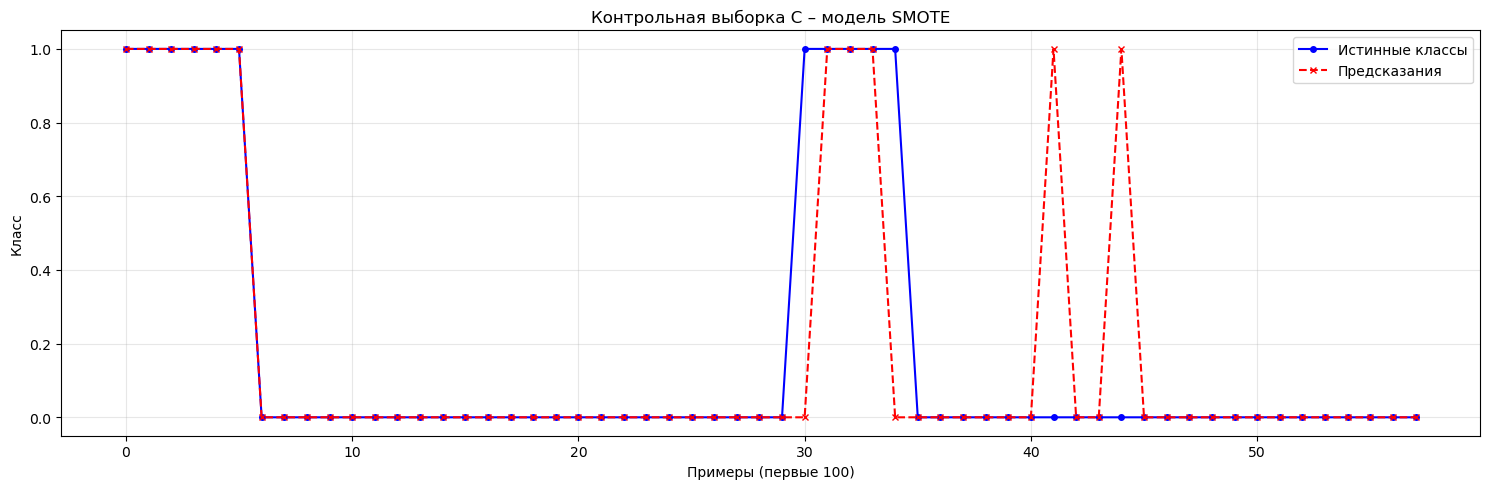

In [44]:
# ------------------------------------------------------------
# 5. График сравнения для лучшей модели на выборке С
# ------------------------------------------------------------

import os
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

y_pred_best = models[best_name][0]

plt.figure(figsize=(15, 5))
plt.plot(Y_C.values[:100], 'bo-', label='Истинные классы', markersize=4)
plt.plot(y_pred_best[:100], 'rx--', label='Предсказания', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title(f'Контрольная выборка С – модель {best_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage5_C_predictions.png', dpi=150)
plt.show()

# 6. Оформление отчёта и выводов

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# Сбор лучших результатов каждого этапа в единую таблицу
# ------------------------------------------------------------
summary_rows = []

# Этап 1 – исходные данные, лучшая модель по cv_acc_mean
best_1 = res_df.loc[res_df['cv_acc_mean'].idxmax()]
summary_rows.append({
    'Этап': '1. Исходные',
    'hidden_layers': best_1['hidden_layers'],
    'activation': best_1['activation'],
    'solver': best_1['solver'],
    'max_iter': best_1['max_iter'],
    'CV Accuracy (mean±std)': f"{best_1['cv_acc_mean']:.3f}±{best_1['cv_acc_std']:.3f}",
    'Train Accuracy': best_1['train_accuracy'],
    'Train F1': best_1['train_f1']
})

# Этап 2 – сортированные данные
if 'res_sort_df' in locals() and not res_sort_df.empty:
    best_2 = res_sort_df.loc[res_sort_df['cv_acc_mean'].idxmax()]
    summary_rows.append({
        'Этап': '2. Сортированные',
        'hidden_layers': best_2['hidden_layers'],
        'activation': best_2['activation'],
        'solver': best_2['solver'],
        'max_iter': best_2['max_iter'],
        'CV Accuracy (mean±std)': f"{best_2['cv_acc_mean']:.3f}±{best_2['cv_acc_std']:.3f}",
        'Train Accuracy': best_2['train_accuracy'],
        'Train F1': best_2['train_f1']
    })
else:
    print("Датафрейм res_sort_df отсутствует – пропускаем этап 2")

# Этап 3 – нормализованные данные
if 'best_norm' in locals():
    summary_rows.append({
        'Этап': '3. Нормализованные',
        'hidden_layers': best_norm['hidden_layers'],
        'activation': best_norm['activation'],
        'solver': best_norm['solver'],
        'max_iter': best_norm['max_iter'],
        'CV Accuracy (mean±std)': f"{best_norm['cv_acc_mean']:.3f}±{best_norm['cv_acc_std']:.3f}",
        'Train Accuracy': best_norm['train_accuracy'],
        'Train F1': best_norm['train_f1']
    })

# Этап 4 – SMOTE
if 'best_smote' in locals():
    summary_rows.append({
        'Этап': '4. SMOTE',
        'hidden_layers': best_smote['hidden_layers'],
        'activation': best_smote['activation'],
        'solver': best_smote['solver'],
        'max_iter': best_smote['max_iter'],
        'CV F1 (mean±std)': f"{best_smote['cv_f1_mean']:.3f}±{best_smote['cv_f1_std']:.3f}",
        'Train Accuracy': best_smote['train_accuracy'],
        'Train F1': best_smote['train_f1']
    })

# Этап 4 – ADASYN
if 'best_adasyn' in locals():
    summary_rows.append({
        'Этап': '4. ADASYN',
        'hidden_layers': best_adasyn['hidden_layers'],
        'activation': best_adasyn['activation'],
        'solver': best_adasyn['solver'],
        'max_iter': best_adasyn['max_iter'],
        'CV F1 (mean±std)': f"{best_adasyn['cv_f1_mean']:.3f}±{best_adasyn['cv_f1_std']:.3f}",
        'Train Accuracy': best_adasyn['train_accuracy'],
        'Train F1': best_adasyn['train_f1']
    })

# Проверка на выборке C (лучшая модель, например SMOTE)
if 'best_name' in locals() and 'Y_C' in locals():
    y_pred_best_C = models[best_name][0]
    acc_C = models[best_name][1]
    f1_C = models[best_name][2]
    summary_rows.append({
        'Этап': f'5. Контроль C ({best_name})',
        'hidden_layers': '-',
        'activation': '-',
        'solver': '-',
        'max_iter': '-',
        'CV Accuracy/F1': '-',
        'Train Accuracy': acc_C,
        'Train F1': f1_C
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Сводная таблица результатов ===")
print(summary_df.to_string(index=False))

=== Сводная таблица результатов ===
                 Этап hidden_layers activation solver max_iter CV Accuracy (mean±std)  Train Accuracy  Train F1 CV F1 (mean±std) CV Accuracy/F1
          1. Исходные         (10,)   logistic   adam      200            0.801±0.006        0.801136  0.000000              NaN            NaN
     2. Сортированные         (50,)   logistic    sgd     1000            0.801±0.006        0.801136  0.000000              NaN            NaN
   3. Нормализованные         (50,)       relu  lbfgs      200            0.852±0.029        0.965909  0.916667              NaN            NaN
             4. SMOTE         (50,)       relu  lbfgs      200                    NaN        0.989362  0.989324      0.938±0.002            NaN
            4. ADASYN         (50,)       relu  lbfgs      200                    NaN        1.000000  1.000000      0.924±0.029            NaN
5. Контроль C (SMOTE)             -          -      -        -                    NaN        0.93103

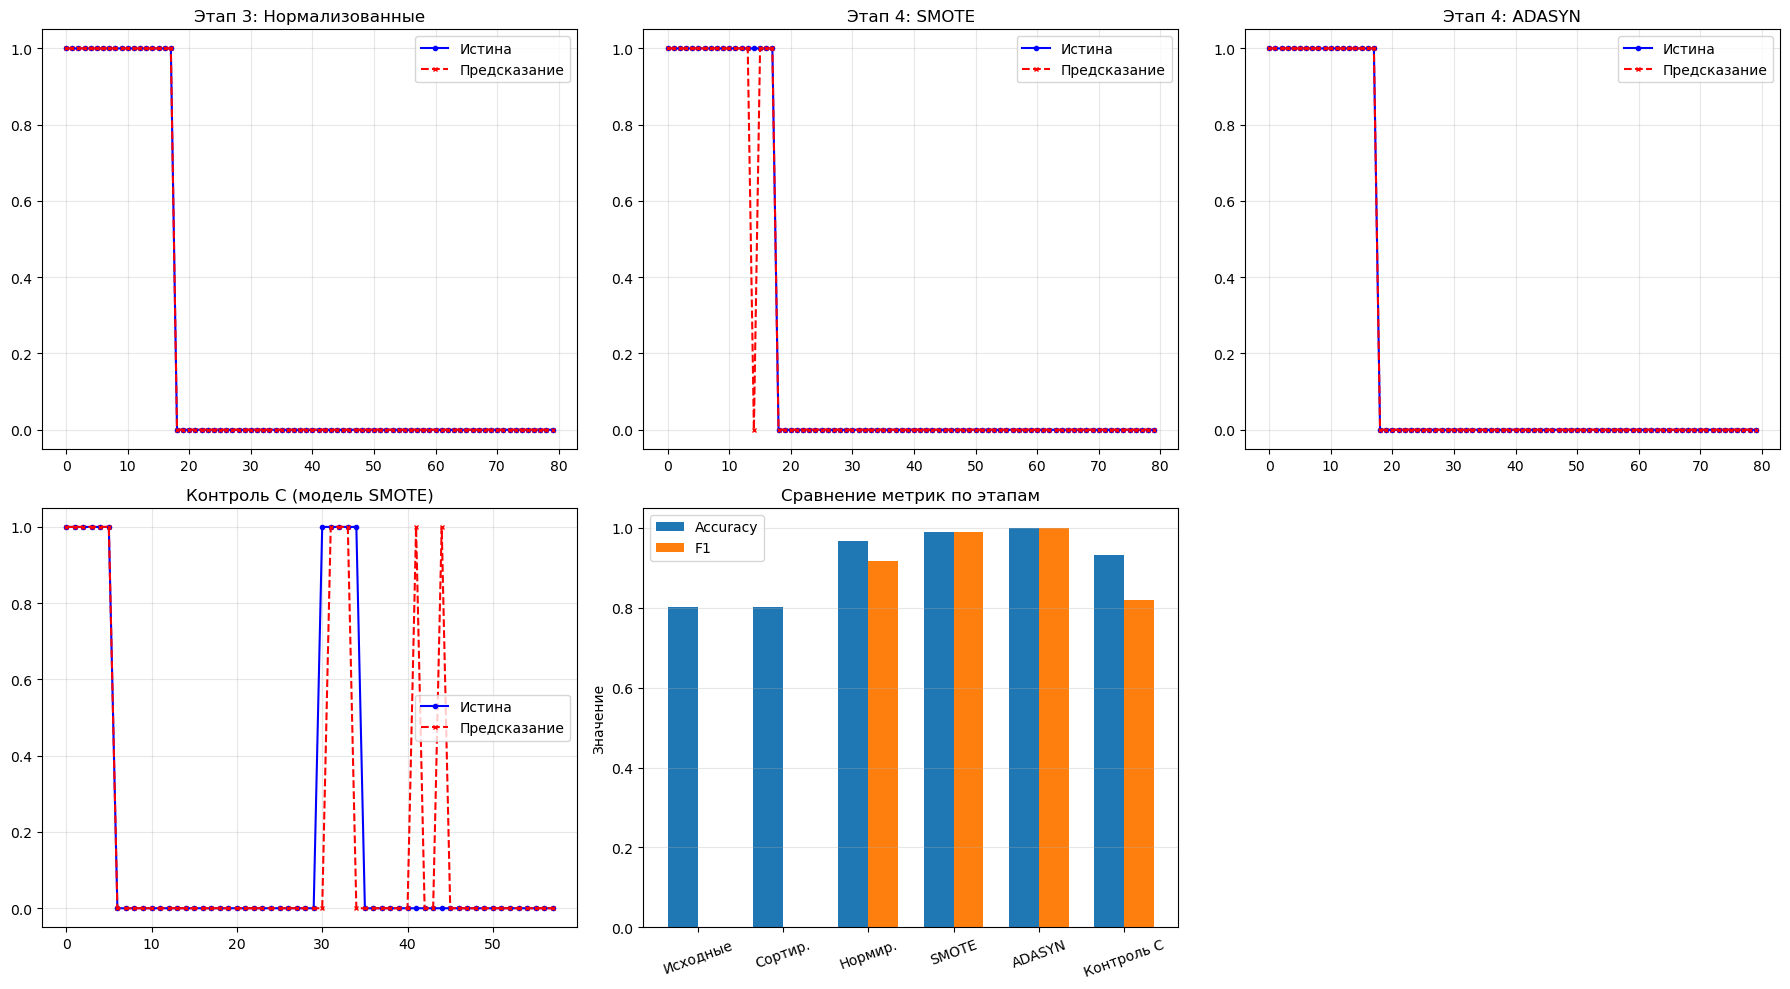

In [50]:
import os
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# ------------------------------------------------------------
# Графики сравнения истинных/предсказанных классов для лучших моделей
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1) Исходные данные (Этап 1) – используем одну из лучших моделей
# Так как у нас может не быть модели Этапа 1 (использовалась только кросс-валидация),
# можно построить график для Этапа 3 (нормализация) или Этапа 4, отражая динамику.
# Возьмём пример для Этапа 3, но если нужна модель Этапа 1, её нужно сохранить ранее.
# Здесь показываю логику: я буду использовать модель best_norm для этапа 3,
# а для этапа 1/2 можно использовать соответствующие модели из results_sort и т.д.
# Для полноты я построю для Этапа 3, SMOTE и ADASYN, а также контроль C.

# Этап 3 – нормализованные (лучшая модель best_norm)
y_pred_norm = best_norm['model'].predict(X_norm)
axes[0].plot(Y_base.values[:80], 'bo-', label='Истина', markersize=3)
axes[0].plot(y_pred_norm[:80], 'rx--', label='Предсказание', markersize=3)
axes[0].set_title('Этап 3: Нормализованные')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Этап 4 – SMOTE (лучшая модель best_smote)
y_pred_smote = best_smote['model'].predict(X_smote)
axes[1].plot(Y_smote[:80], 'bo-', label='Истина', markersize=3)
axes[1].plot(y_pred_smote[:80], 'rx--', label='Предсказание', markersize=3)
axes[1].set_title('Этап 4: SMOTE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Этап 4 – ADASYN
y_pred_adasyn = best_adasyn['model'].predict(X_adasyn)
axes[2].plot(Y_adasyn[:80], 'bo-', label='Истина', markersize=3)
axes[2].plot(y_pred_adasyn[:80], 'rx--', label='Предсказание', markersize=3)
axes[2].set_title('Этап 4: ADASYN')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Контрольная выборка C (лучшая модель, напр. SMOTE)
y_pred_C_final = models[best_name][0]
axes[3].plot(Y_C.values[:80], 'bo-', label='Истина', markersize=3)
axes[3].plot(y_pred_C_final[:80], 'rx--', label='Предсказание', markersize=3)
axes[3].set_title(f'Контроль C (модель {best_name})')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Дополнительно: сравнение этапов по метрикам (гистограмма)
# Собираем данные для всех этапов
stages = ['Исходные', 'Сортир.', 'Нормир.', 'SMOTE', 'ADASYN', 'Контроль C']
acc_values = [best_1['train_accuracy'], best_2['train_accuracy'] if 'best_2' in locals() else None,
              best_norm['train_accuracy'], best_smote['train_accuracy'], best_adasyn['train_accuracy'], acc_C]
f1_values = [best_1['train_f1'], best_2['train_f1'] if 'best_2' in locals() else None,
             best_norm['train_f1'], best_smote['train_f1'], best_adasyn['train_f1'], f1_C]

# Убираем None
filtered = [(s, a, f) for s, a, f in zip(stages, acc_values, f1_values) if a is not None]
stages_f, acc_f, f1_f = zip(*filtered)

x = np.arange(len(stages_f))
width = 0.35
axes[4].bar(x - width/2, acc_f, width, label='Accuracy')
axes[4].bar(x + width/2, f1_f, width, label='F1')
axes[4].set_xticks(x)
axes[4].set_xticklabels(stages_f, rotation=20)
axes[4].set_ylabel('Значение')
axes[4].set_title('Сравнение метрик по этапам')
axes[4].legend()
axes[4].grid(axis='y', alpha=0.3)

# Скрыть пустой последний подграфик
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'{plot_dir}\\summary_results.png', dpi=150, bbox_inches='tight')
plt.show()